# Scans

1d and 2d scans over various intersting input parameters

In [1]:
from impact import Impact, run_impact_with_distgen
from distgen import Generator

from concurrent.futures import ProcessPoolExecutor
import os

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [2]:
# Allows processes to work with macOS
from sys import platform
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [3]:
GFILE = '$LCLS_LATTICE/distgen/models/cu_inj/v0/distgen.yaml'
YFILE = os.path.expandvars('$LCLS_LATTICE/impact/models/cu_inj/v0/ImpactT.yaml')

# Initial setup and test

In [4]:
G = Generator(GFILE)
G['t_dist:length:value'] = 3
G

<disgten.Generator with input: 
n_particle: 100000
r_dist:
  n_sigma_cutoff: 1.5
  sigma_xy:
    units: mm
    value: 0.37
  type: radial_gaussian
random_type: hammersley
start:
  MTE:
    units: meV
    value: 414
  type: cathode
t_dist:
  length:
    units: ps
    value: 3
  ratio:
    units: ''
    value: 0.8
  type: tukey
total_charge:
  units: pC
  value: 250

>

# Parallel Scans

## Scan `SOL1:solenoid_field_scale`

In [5]:
%%time

SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':4.62 }
KEY1 = 'SOL1:solenoid_field_scale'

def set1(x):
    settings = SETTINGS0.copy()
    settings[KEY1] = x
    I = run_impact_with_distgen(settings, impact_config=YFILE, distgen_input_file=GFILE)
    return I
    
#set1(0.2457)

CPU times: user 3 µs, sys: 2 µs, total: 5 µs
Wall time: 7.63 µs


In [6]:
# Scan list
xlist = np.linspace(0.24, 0.26, 16)
xlist 

array([0.24      , 0.24133333, 0.24266667, 0.244     , 0.24533333,
       0.24666667, 0.248     , 0.24933333, 0.25066667, 0.252     ,
       0.25333333, 0.25466667, 0.256     , 0.25733333, 0.25866667,
       0.26      ])

In [7]:
%%time
with ProcessPoolExecutor(max_workers=16) as executor:
    results1 = list(executor.map(set1, xlist))

CPU times: user 127 ms, sys: 137 ms, total: 264 ms
Wall time: 8min 30s


Text(0, 0.5, 'norm_emit_x (mm-mrad)')

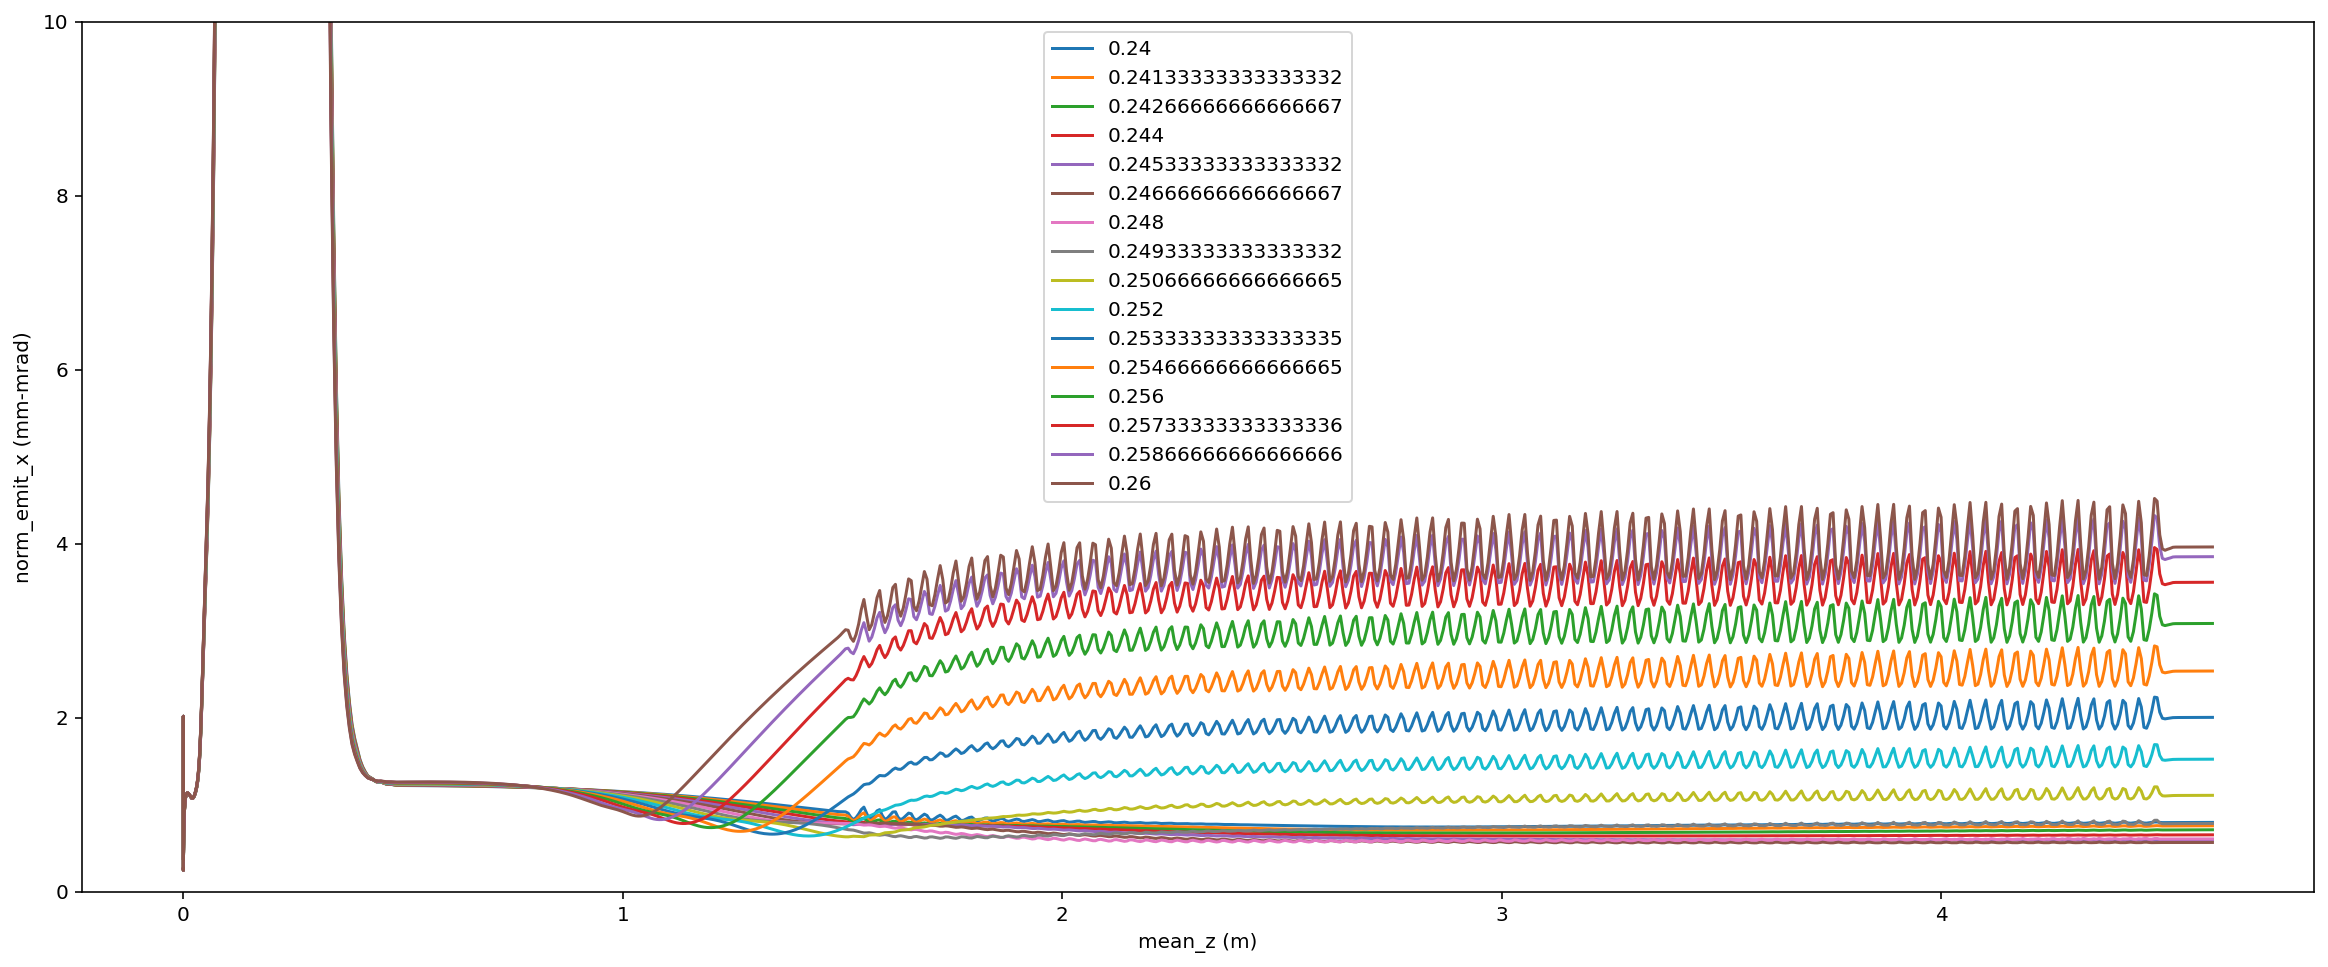

In [8]:
fig, ax = plt.subplots(figsize=(20,8))

k1 = 'mean_z'
k2 = 'norm_emit_x'

f1 = 1
f2 = 1e6

for dt, I in zip(xlist, results1):
    x = I.stat(k1)*f1
    y = I.stat(k2)*f2

    ax.plot(x, y, label=dt)
    
ax.set_ylim(0, 10)    
ax.legend()    
ax.set_xlabel(k1 + ' (m)')
ax.set_ylabel(k2 + ' (mm-mrad)')
    

Text(0.5, 0, 'SOL1:solenoid_field_scale')

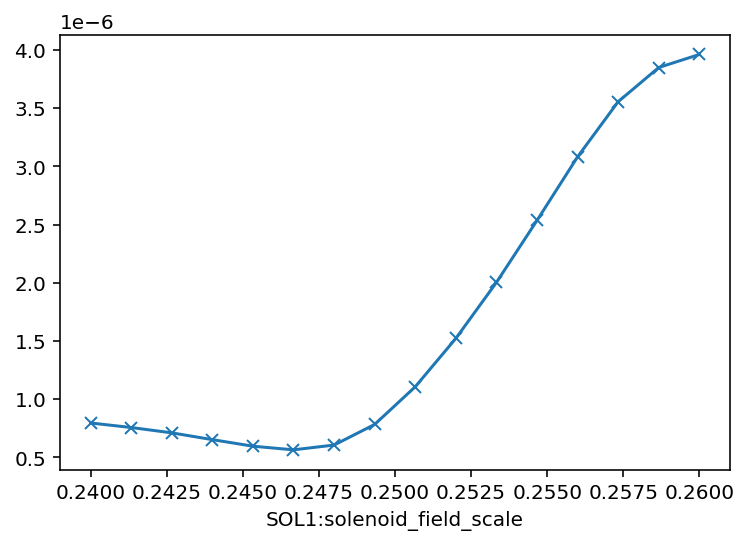

In [9]:
emits = [I.stat('norm_emit_x')[-1] for I in results1]

plt.plot(xlist, emits, marker='x')
plt.xlabel(KEY1)

# Scan `L0A_phase:dtheta0_deg`

In [10]:
# Scan list
xlist = np.linspace(-10, 10, 16)
xlist 

array([-10.        ,  -8.66666667,  -7.33333333,  -6.        ,
        -4.66666667,  -3.33333333,  -2.        ,  -0.66666667,
         0.66666667,   2.        ,   3.33333333,   4.66666667,
         6.        ,   7.33333333,   8.66666667,  10.        ])

In [11]:
%%time
SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':4.62 }
KEY1 = 'L0A_phase:dtheta0_deg'

with ProcessPoolExecutor(max_workers=16) as executor:
    results1 = list(executor.map(set1, xlist))

CPU times: user 74.4 ms, sys: 227 ms, total: 301 ms
Wall time: 8min 35s


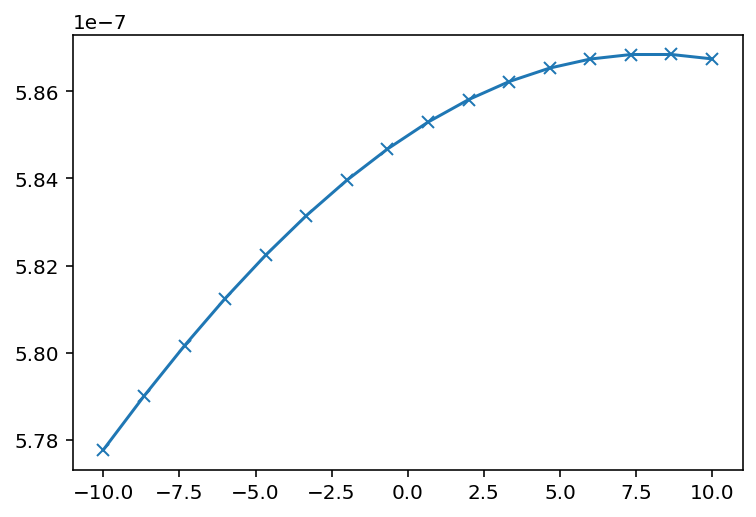

In [12]:
emits = [I.stat('norm_emit_x')[-1] for I in results1]

plt.plot(xlist, emits, marker='x')

Text(0.5, 0, 'L0A_phase:dtheta0_deg')

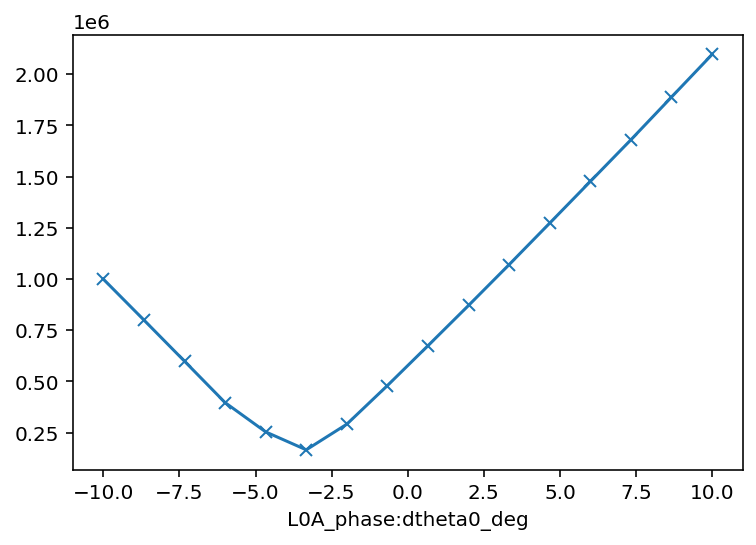

In [13]:
emits = [I.particles['final_particles']['ptp_pz'] for I in results1]

plt.plot(xlist, emits, marker='x')
plt.xlabel(KEY1)

# Scan `L0B_phase:dtheta0_deg`

In [14]:
# Scan list
xlist = np.linspace(-10, 10, 16)
xlist 

array([-10.        ,  -8.66666667,  -7.33333333,  -6.        ,
        -4.66666667,  -3.33333333,  -2.        ,  -0.66666667,
         0.66666667,   2.        ,   3.33333333,   4.66666667,
         6.        ,   7.33333333,   8.66666667,  10.        ])

In [15]:
%%time
SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':8.39 }
KEY1 = 'L0B_phase:dtheta0_deg'

with ProcessPoolExecutor(max_workers=16) as executor:
    results1 = list(executor.map(set1, xlist))

CPU times: user 115 ms, sys: 292 ms, total: 407 ms
Wall time: 11min 37s


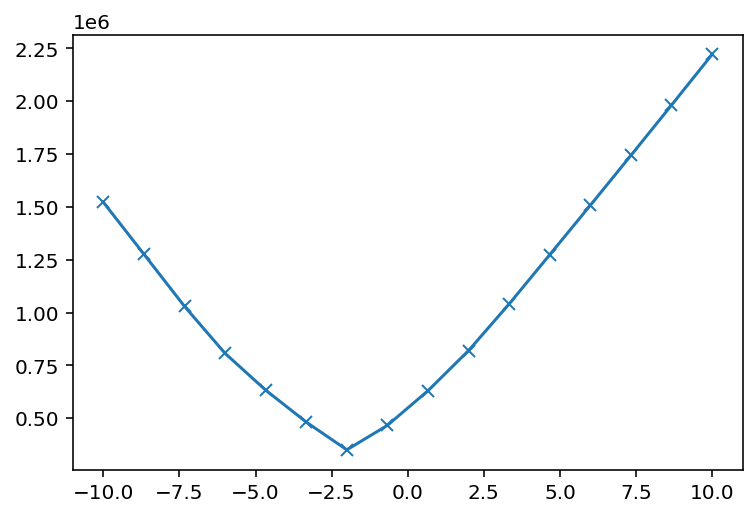

In [16]:
emits = [I.particles['final_particles']['ptp_pz'] for I in results1]

plt.plot(xlist, emits, marker='x')

## 2D Scan: `distgen:t_dist:length:value` vs `SOL1:solenoid_field_scale`

In [17]:
xlist = np.linspace(3, 8, 16)
ylist = np.linspace(0.24, 0.26, 16)
X, Y = np.meshgrid(xlist, ylist)

In [18]:
%%time

SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':4.62}

KEY1 = 'distgen:t_dist:length:value'
KEY2 = 'SOL1:solenoid_field_scale'

def set2(x, y):
    settings = SETTINGS0.copy()
    settings[KEY1] = x
    settings[KEY2] = y
    I = run_impact_with_distgen(settings, impact_config=YFILE, distgen_input_file=GFILE)
    return I


#set2(3, 0.243)

CPU times: user 4 µs, sys: 2 µs, total: 6 µs
Wall time: 8.58 µs


In [19]:
%%time
with ProcessPoolExecutor(max_workers=16) as executor:
    results2 = list(executor.map(set2, X.flatten(), Y.flatten()))

CPU times: user 1.82 s, sys: 1.8 s, total: 3.62 s
Wall time: 2h 12min 42s


In [20]:
len(Y)

16

(0.0, 2.0)

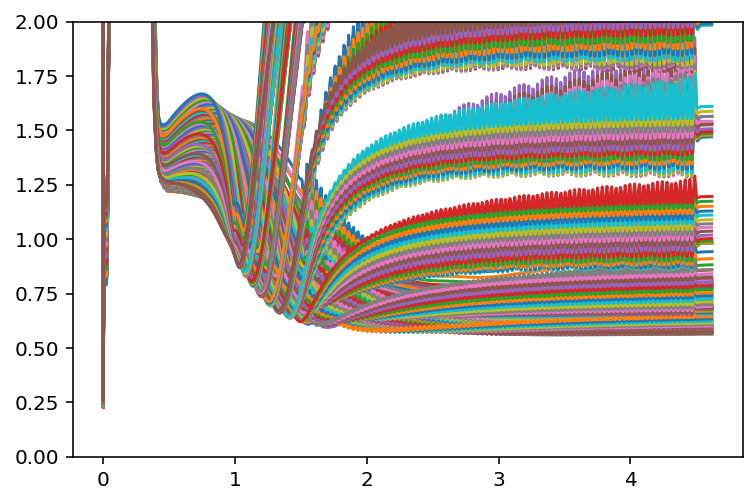

In [21]:
fig, ax = plt.subplots()
#ax.plot(Iref2.stat('mean_z'), Iref2.stat('norm_emit_x')*1e6)
for I in results2:
    ax.plot(I.stat('mean_z'), I.stat('norm_emit_x')*1e6) 
ax.set_ylim(0,2)    

In [22]:
def extract_stat(key):
    return np.array([I.stat(key)[-1] for I in results2]).reshape(X.shape)
def extract_pstat(key):
    return np.array([I.particles['final_particles'][key] for I in results2]).reshape(X.shape)

Text(0.5, 1.0, 'norm_emit_4d')

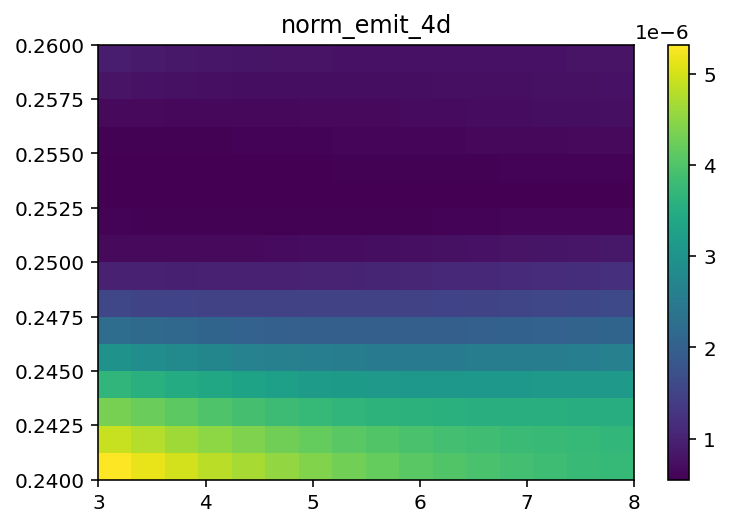

In [23]:
KEY = 'norm_emit_4d'
Z = extract_pstat(KEY)
plt.imshow(np.sqrt(Z), extent=[xlist.min(), xlist.max(), ylist.min(), ylist.max()], aspect='auto')
plt.colorbar()
plt.title(KEY)

<a list of 9 text.Text objects>

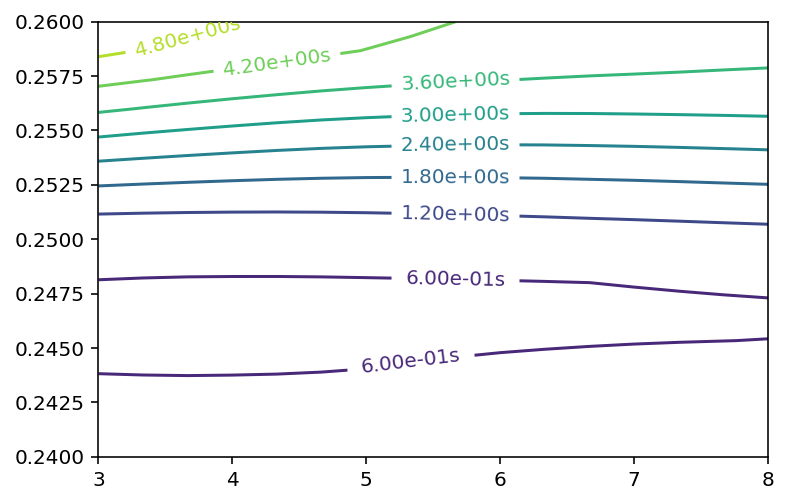

In [24]:
fig, ax = plt.subplots()
CS = ax.contour(X, Y, 1e6*np.sqrt(Z))

ax.clabel(CS, CS.levels, inline=True, fmt='%2.2es', fontsize=10)

In [25]:
# Find the minimum
A = np.sqrt(Z)
I8 = results2[A.argmin()]
ii = np.unravel_index(A.argmin(), A.shape)
ii, X[ii], Y[ii], np.sqrt(Z[ii])

((4, 1), 3.3333333333333335, 0.24533333333333332, 5.515286687498898e-07)

# Laser radius and solenoid

In [ ]:
xlist = np.linspace(0.2, 0.5, 8)
ylist = np.linspace(0.24, 0.26, 8)
X, Y = np.meshgrid(xlist, ylist)
X

array([[0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ],
       [0.2       , 0.24285714, 0.28571429, 0.32857143, 0.37142857,
        0.41428571, 0.45714286, 0.5       ]])

In [ ]:
%%time

SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':4.62}

KEY1 =  'distgen:r_dist:sigma_xy:value'   #: [0.2, 0.5] # mm, diameter = 3*this, because cutoff is 1.5 sigma. This is therefore [0.6, 1.5] mm
#    'distgen:t_dist:length:value'  #: [3.0, 12.0]  # ps tukey length = 1.65 * FWHM /ps, with FWHM range [1.85, 7] p
KEY2 = 'SOL1:solenoid_field_scale'

with ProcessPoolExecutor(max_workers=16) as executor:
    results3 = list(executor.map(set2, X.flatten(), Y.flatten()))

CPU times: user 367 ms, sys: 1.16 s, total: 1.53 s
Wall time: 32min 19s


In [ ]:
def extract_stat(key):
    return np.array([I.stat(key)[-1] for I in results3]).reshape(X.shape)
def extract_pstat(key):
    return np.array([I.particles['final_particles'][key] for I in results3]).reshape(X.shape)

Text(0.5, 1.0, 'norm_emit_4d')

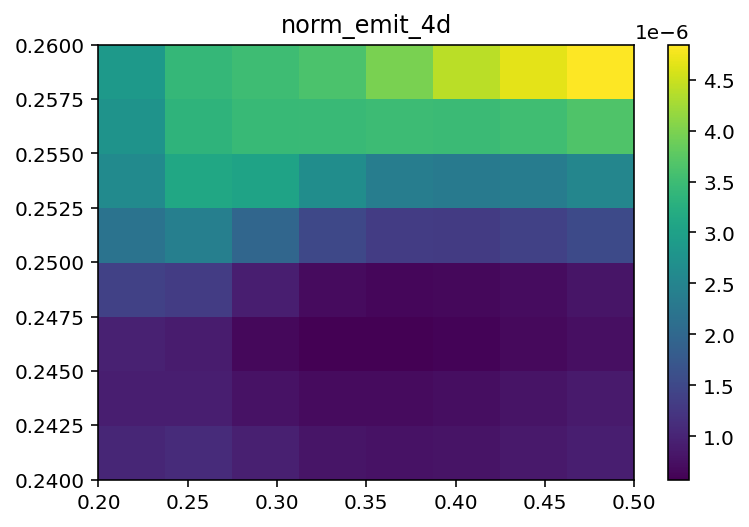

In [ ]:
KEY = 'norm_emit_4d'
Z = extract_pstat(KEY)
plt.imshow(np.sqrt(Z), extent=[xlist.min(), xlist.max(), ylist.min(), ylist.max()], aspect='auto', origin='lower')
plt.colorbar()
plt.title(KEY)

<a list of 7 text.Text objects>

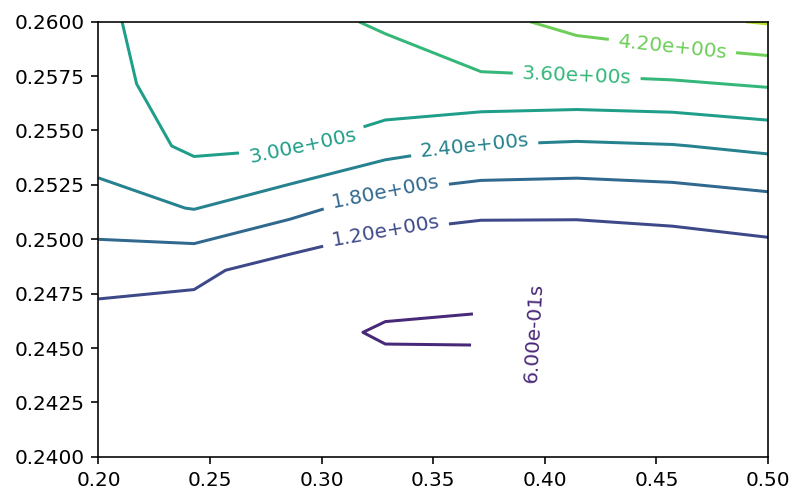

In [ ]:
fig, ax = plt.subplots()
CS = ax.contour(X, Y, 1e6*np.sqrt(Z))

ax.clabel(CS, CS.levels, inline=True, fmt='%2.2es', fontsize=10)

In [ ]:
A = np.sqrt(Z)
I8 = results3[A.argmin()]
ii = np.unravel_index(A.argmin(), A.shape)
ii, X[ii], Y[ii], np.sqrt(Z[ii]), 

((2, 4), 0.37142857142857144, 0.24571428571428572, 5.754780126278801e-07)

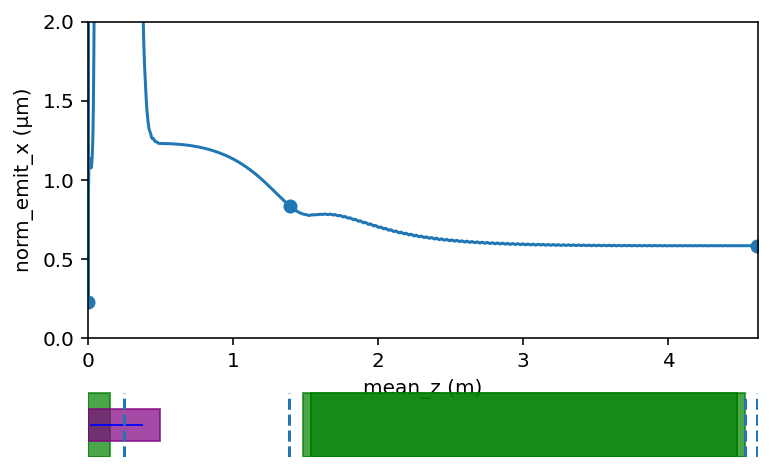

In [ ]:
I8.plot('norm_emit_x', ylim=(0,2e-6))

In [ ]:
I8.initial_particles['sigma_t']

1.2793997643319811e-12

In [ ]:
I8.configure()
I8.write_input()
I8.path

'/tmp/tmpo74rrjkg'

<a list of 7 text.Text objects>

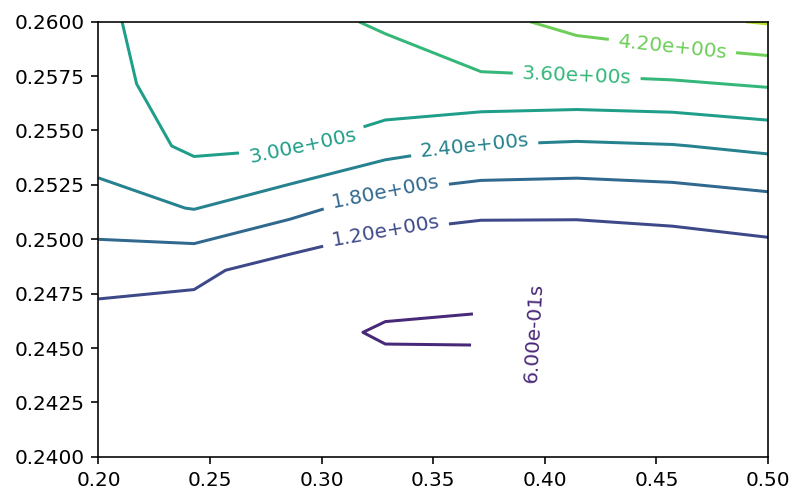

In [ ]:
fig, ax = plt.subplots()
CS = ax.contour(X, Y, 1e6*np.sqrt(Z))

ax.clabel(CS, CS.levels, inline=True, fmt='%2.2es', fontsize=10)

# Timestep `change_timestep_1:dt`

In [ ]:
# Scan time in powers of 2
xlist = [4e-12 * 2**n for n in range(-3,4) ] 
xlist 

[5e-13, 1e-12, 2e-12, 4e-12, 8e-12, 1.6e-11, 3.2e-11]

In [ ]:
%%time
SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':4.62 }
KEY1 = 'change_timestep_1:dt'

with ProcessPoolExecutor(max_workers=16) as executor:
    results4 = list(executor.map(set1, xlist))

CPU times: user 57.9 ms, sys: 1.07 s, total: 1.13 s
Wall time: 27min 25s


(0.0, 2.0)

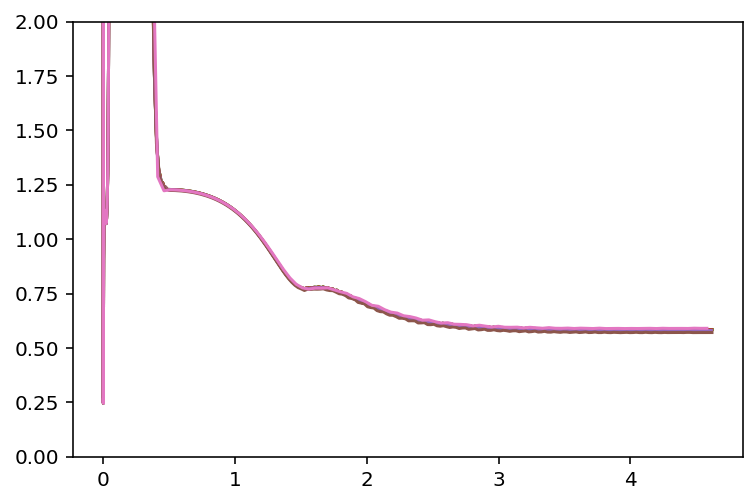

In [ ]:
fig, ax = plt.subplots()
for I in results4:
    ax.plot(I.stat('mean_z'), I.stat('norm_emit_x')*1e6) 
ax.set_ylim(0,2)    

# SC off

In [ ]:
%%time

SETTINGS0 = {'distgen:n_particle':10000, 'stop_1:s':16.5}
KEY1 = 'SC_OFF:s'

    
#set1(0.2)

CPU times: user 3 µs, sys: 2 µs, total: 5 µs
Wall time: 7.63 µs


In [ ]:
xlist = np.linspace(4, 16, 16)
xlist

array([ 4. ,  4.8,  5.6,  6.4,  7.2,  8. ,  8.8,  9.6, 10.4, 11.2, 12. ,
       12.8, 13.6, 14.4, 15.2, 16. ])

In [ ]:
%%time
with ProcessPoolExecutor(max_workers=16) as executor:
    results5 = list(executor.map(set1, xlist))

CPU times: user 163 ms, sys: 1.17 s, total: 1.33 s
Wall time: 15min 40s


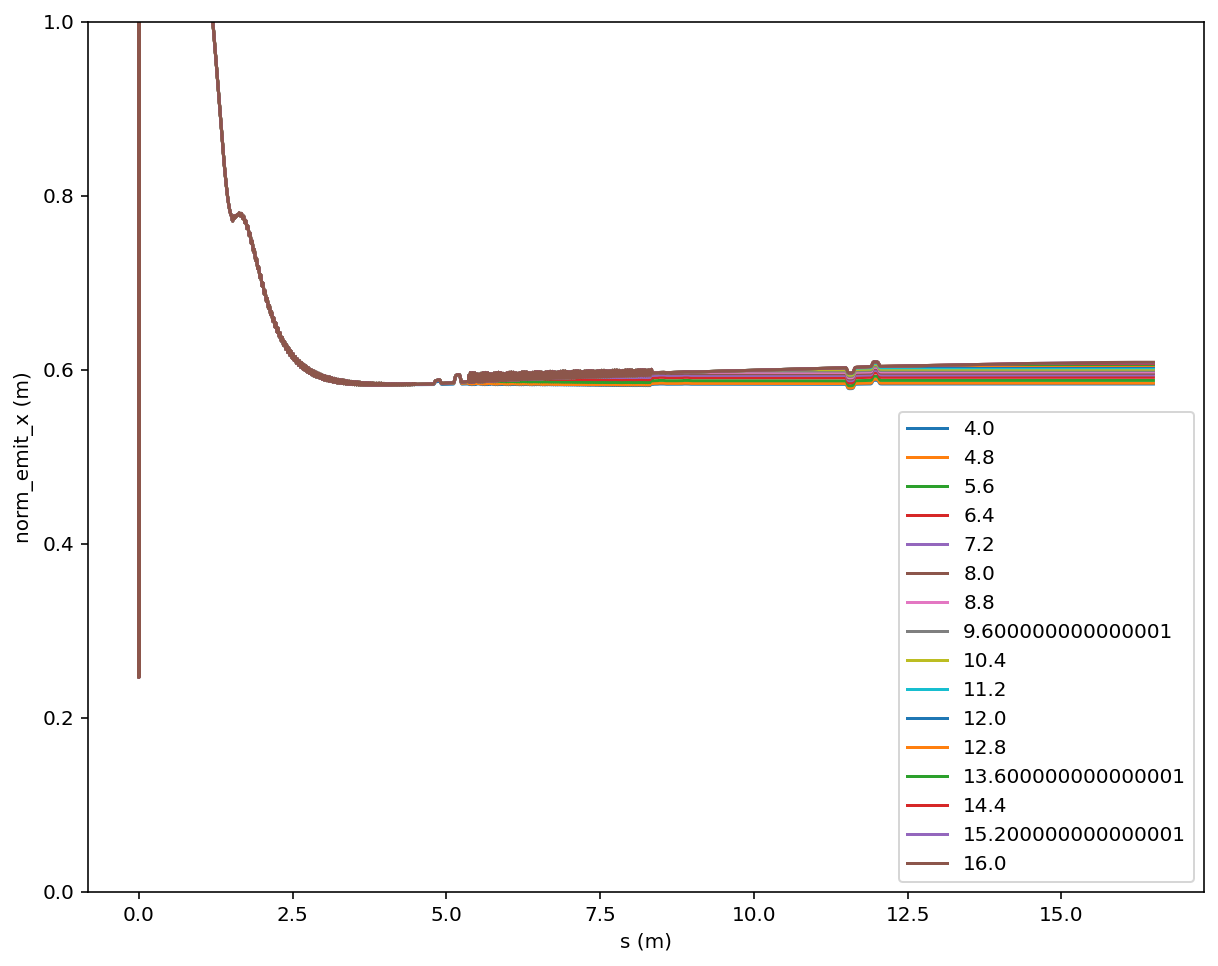

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
for I, s in zip(results5, xlist):
    ax.plot(I.stat('mean_z'), I.stat('norm_emit_x')*1e6, label=s) 
ax.set_ylim(0,1)    
ax.set_xlabel('s (m)')
ax.set_ylabel('norm_emit_x (m)')
plt.legend()

Text(0.5, 0, 's for SC off (m)')

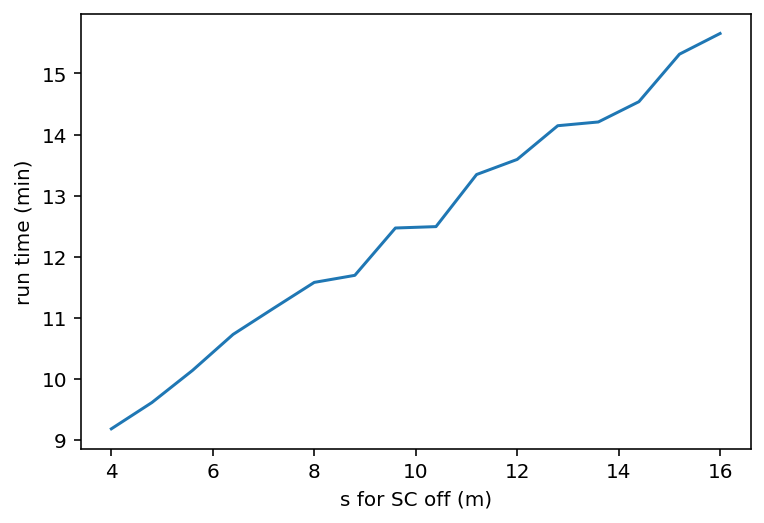

In [ ]:
plt.plot(xlist, [r.output['run_info']['run_time']/60 for r in results5])
plt.ylabel('run time (min)')
plt.xlabel('s for SC off (m)')

Text(0.5, 0, 's for SC off (m)')

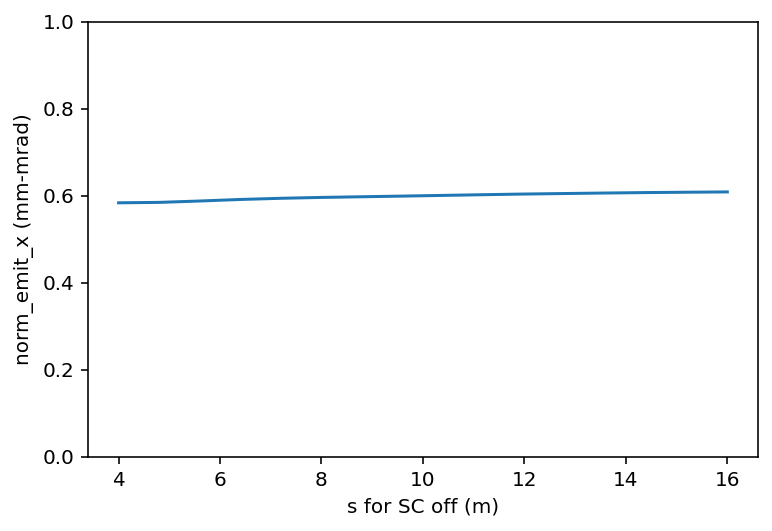

In [ ]:
plt.plot(xlist, [1e6*r.stat('norm_emit_x')[-1] for r in results5])
plt.ylim(0,1)
plt.ylabel('norm_emit_x (mm-mrad)')
plt.xlabel('s for SC off (m)')

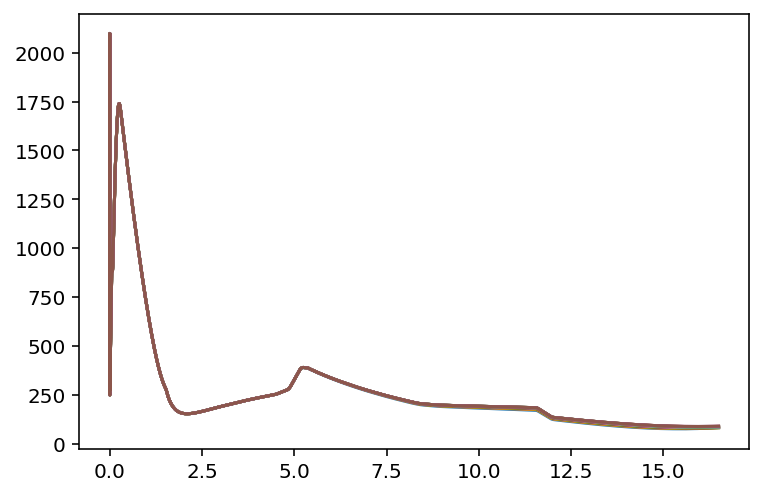

In [ ]:
fig, ax = plt.subplots()
for I in results5:
    ax.plot(I.stat('mean_z'), I.stat('sigma_x')*1e6) 
#ax.set_ylim(0,2)    

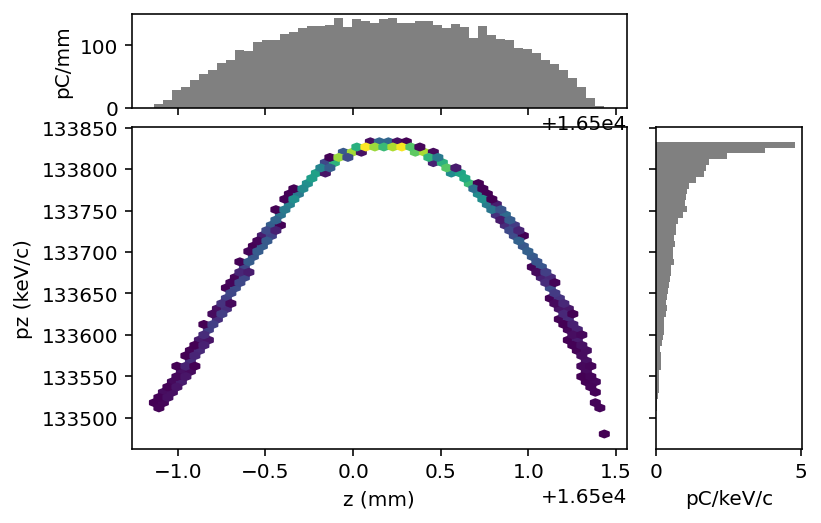

In [ ]:
results5[0].particles['final_particles'].plot('z', 'pz')

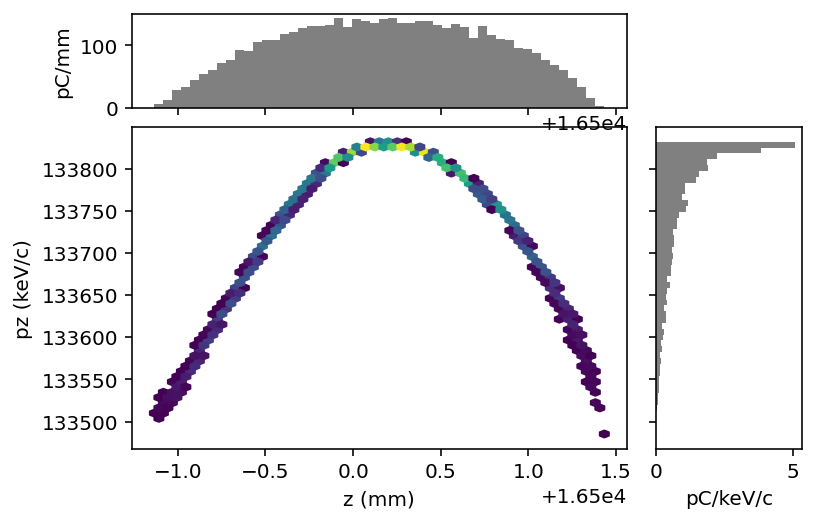

In [ ]:
results5[-1].particles['final_particles'].plot('z', 'pz')